In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import time
import re
import matplotlib.pyplot as plt
import json

In [2]:
def get_url(url):
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'}
    r=requests.get(url, headers=headers)
    return r

def get_mof_data(page=0):
    if page==0:
        url='https://www.mof.gov.cn/gkml/caizhengshuju/index.htm'
    else:
        url=f'https://www.mof.gov.cn/gkml/caizhengshuju/index_{page}.htm'
    r=get_url(url)
    soup=BeautifulSoup(r.content)
    links=soup.find('div', {'class': 'mainboxerji'}).find_all('a')
    lst_links=[]
    domain=r'https://www.mof.gov.cn/gkml/caizhengshuju'
    for link in links:
        dict_link={}
        dict_link['title']=link.text
        if re.search(r'^\.\.(\/\.\.)?', link.get('href')):
            dict_link['link']=re.sub(r'^\.\.(\/\.\.)?', 'https://www.mof.gov.cn', 
                                     link.get('href'))
        else:
            dict_link['link']=re.sub(r'^\.', domain, link.get('href'))
        lst_links.append(dict_link)
    return lst_links

In [3]:
def get_links(start, end):
    # get all the link from all pages
    links=[]
    for page in range(start, end):
        links=links+get_mof_data(page)
    return links

In [4]:
def get_fin_text(url):
    time.sleep(2)
    r=get_url(url)
    soup=BeautifulSoup(r.content)
    content=soup.find('div', {'class': 'my_doccontent'})
    return content.text

In [93]:
def parse_income_text(content):
    dict_regex={
        #一般公共预算收入情况
        '全国一般公共预算收入': r'全国(?:一般)?(?:公共)?(?:预算|财政)收入([\d,\.]+亿)',
        '中央一般公共预算收入': r'中央(?:本级)?(?:一般公共)?(?:预算|财政)?收入([\d\,\.]+亿)',
        '地方一般公共预算本级收入': r'地方(?:本级)?(?:一般公共)?(?:预算|财政)?(?:本级)?收入(?:[\（\(]本级[\）\)])?([\d,\.]+亿)', # r'地方(?:本级)?(?:一般公共)?(?:预算|财政)(?:本级)?收入(?:\(本級\))?([\d\,\.]+亿)',
        '税收收入': r'税收收入([\d\,\.]+亿)',
        '非税收入': r'非税收入([\d\,\.]+亿)',
        '国内增值税': r'国内增值税([\d\,\.]+亿)',
        '国内消费税': r'国内消费税([\d\,\.]+亿)',
        '企业所得税': r'企业所得税([\d\,\.]+亿)',
        '个人所得税': r'个人所得税([\d\,\.]+亿)',
        '进口货物增值税消费税': r'进口货物增值税、消费税([\d\,\.]+亿)',
        '关税': r'关税([\d\,\.]+亿)',
        '出口退税': r'出口退税([\d\,\.]+亿)',
        '城市维护建设税': r'城市维护建设税([\d\,\.]+亿)',
        '车辆购置税': r'车辆购置税([\d\,\.]+亿)',
        '印花税': r'印花税([\d\,\.]+亿)',
        '资源税': r'资源税([\d\,\.]+亿)',
        '契税': r'契税([\d\,\.]+亿)',
        '房产税': r'房产税([\d\,\.]+亿)',
        '城镇土地使用税': r'城镇土地使用税([\d\,\.]+亿)',
        '土地增值税': r'土地增值税([\d\,\.]+亿)',
        '耕地占用税': r'耕地占用税([\d\,\.]+亿)',
        '环境保护税': r'环境保护税([\d\,\.]+亿)',
        '其他各项税收收入': r'其他各项税收收入.*?([\d\,\.]+亿)',

        # #一般公共预算支出情况
        # '全国一般公共预算支出': r'全国一般公共预算支出.*?([\d\,\.]+亿)',
        # '中央一般公共预算本级支出': r'中央一般公共预算本级支出.*?([\d\,\.]+亿)',
        # '地方一般公共预算支出': r'地方一般公共预算支出.*?([\d\,\.]+亿)',
        '全国一般公共预算支出': r'全国(?:一般)?(?:公共)?(?:预算|财政)支出([\d,\.]+亿)',
        '中央一般公共预算本级支出': r'中央(?:本级)?(?:一般公共)?(?:预算|财政)?(?:本级)?支出([\d\,\.]+亿)',
        '地方一般公共预算支出':r'地方(?:本级)?(?:一般公共)?(?:预算|财政)?(?:本级)?支出(?:[\（\(]本级[\）\)])?([\d,\.]+亿)',
        '教育支出': r'教育支出.*?([\d\,\.]+亿)',
        '科学技术支出': r'科学技术支出.*?([\d\,\.]+亿)',
        '文化旅游体育与传媒支出': r'文化旅游体育与传媒支出.*?([\d\,\.]+亿)',
        '社会保障和就业支出': r'社会保障和就业支出.*?([\d\,\.]+亿)',
        '卫生健康支出': r'卫生健康支出.*?([\d\,\.]+亿)',
        '节能环保支出': r'节能环保支出.*?([\d\,\.]+亿)',
        '城乡社区支出': r'城乡社区支出.*?([\d\,\.]+亿)',
        '农林水支出': r'农林水支出.*?([\d\,\.]+亿)',
        '交通运输支出': r'交通运输支出.*?([\d\,\.]+亿)',
        '债务付息支出': r'债务付息支出.*?([\d\,\.]+亿)',

        #全国政府性基金预算
        '全国政府性基金预算收入': r'全国政府性基金预算收入.*?([\d\,\.]+亿)',
        '中央政府性基金预算收入': r'中央政府性基金预算收入.*?([\d\,\.]+亿)',
        '方政府性基金预算本级收入': r'方政府性基金预算本级收入.*?([\d\,\.]+亿)',
        '国有土地使用权出让收入': r'国有土地使用权出让收入.*?([\d,\.]+亿)',
        '全国政府性基金预算支出': r'全国政府性基金预算支出.*?([\d,\.]+亿)',
        '中央政府性基金预算本级支出': r'中央政府性基金预算本级支出.*?([\d,\.]+亿)',
        '地方政府性基金预算支出': r'地方政府性基金预算支出.*?([\d,\.]+亿)',
        '国有土地使用权出让收入相关支出': r'国有土地使用权出让收入相关支出.*?([\d,\.]+亿)'
    }

    dict_result={key: None for key in dict_regex.keys()}
    for key, regex in dict_regex.items():
        # try:
            if re.search(regex, content):
                dict_result[key]=float(re.search(regex, content).group(1).replace('亿', ''))
            else:
                dict_result[key]=None
        # except:
            # print(key)

    return dict_result

In [6]:
links=get_links(0,20)
fin_link=[item for item in links if '收支' in item['title']]
contents=[get_fin_text(item['link']) for item in fin_link]


In [72]:
index=[re.search(r'(.*?)财政收支情况', item['title']).group(1) for item in fin_link]
index=[re.sub('年$', '年12月', re.sub('1-', '', re.sub('前三季度', '9月', re.sub('一季度', '3月', re.sub('上半年', '6月',  re.sub('公共|份', '', i))))))
        for i in index]
content_dict=dict(zip(index, contents))

In [ ]:
with open('MOF_contents.json', 'r', encoding='UTF-8') as f:
	old_content_dict = json.load(f)

old_content_dict.update(content_dict)

with open('MOF_contents.json', 'w', encoding='UTF-8') as f:
    json.dump(old_content_dict, f, indent=4)

In [7]:
with open('MOF_contents.json', 'r', encoding='UTF-8') as f:
	content_dict = json.load(f)


In [94]:
# results=[parse_income_text(content) for content in contents]
results={key: parse_income_text(content) for key, content in content_dict.items()}
# index=[re.search(r'(.*?)财政收支情况', item['title']).group(1) for item in fin_link]

In [95]:
df=pd.DataFrame(results).T
df.index=pd.to_datetime(df.index, format='%Y年%m月')
df['出口退税']=df['出口退税']*-1
df

,全国一般公共预算收入,中央一般公共预算收入,地方一般公共预算本级收入,税收收入,非税收入,国内增值税,国内消费税,企业所得税,个人所得税,进口货物增值税消费税,...,交通运输支出,债务付息支出,全国政府性基金预算收入,中央政府性基金预算收入,方政府性基金预算本级收入,国有土地使用权出让收入,全国政府性基金预算支出,中央政府性基金预算本级支出,地方政府性基金预算支出,国有土地使用权出让收入相关支出
2025-12-01,216045.00,93963.00,122082.00,176363.00,39682.00,68947.00,16857.00,41304.00,16187.00,18263.00,...,11977.00,13491.0,57704.0,5056.0,52648.0,41518.0,112874.0,10984.0,101890.0,47120.0
2025-11-01,200516.00,88464.00,112052.00,164814.00,35702.00,63629.00,15639.00,40234.00,14689.00,16520.00,...,10177.00,12189.0,40274.0,3938.0,36336.0,29119.0,92124.0,9078.0,83046.0,38489.0
2025-10-01,186490.00,81856.00,104634.00,153364.00,33126.00,58858.00,14390.00,39182.00,13363.00,15007.00,...,9199.00,10952.0,34473.0,3618.0,30855.0,24982.0,80892.0,8564.0,72328.0,33752.0
2025-09-01,163876.00,70837.00,93039.00,132664.00,31212.00,52271.00,12934.00,32527.00,11799.00,13465.00,...,8470.00,9819.0,30717.0,3276.0,27441.0,22302.0,74924.0,8090.0,66834.0,31383.0
2025-08-01,148198.00,64268.00,83930.00,121085.00,27113.00,47389.00,11523.00,31477.00,10547.00,11770.00,...,7128.00,8715.0,26449.0,2933.0,23516.0,19263.0,62602.0,7609.0,54993.0,26732.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-07-01,9864.10,5228.59,4635.51,58708.04,8031.88,1754.94,548.62,2623.02,505.84,1171.31,...,3299.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-01,10055.76,4459.51,5596.25,50028.43,6847.39,12431.30,3760.75,11175.36,3554.78,7168.63,...,2561.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-05-01,10612.26,6186.38,4425.88,41896.23,4923.83,1952.29,562.00,3331.32,502.06,1173.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-04-01,10082.06,5214.08,4867.98,32631.52,3576.28,1826.82,561.26,2848.24,502.11,1169.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
df.to_csv('MOF.csv')

In [97]:
df.columns

Index(['全国一般公共预算收入', '中央一般公共预算收入', '地方一般公共预算本级收入', '税收收入', '非税收入', '国内增值税',
       '国内消费税', '企业所得税', '个人所得税', '进口货物增值税消费税', '关税', '出口退税', '城市维护建设税',
       '车辆购置税', '印花税', '资源税', '契税', '房产税', '城镇土地使用税', '土地增值税', '耕地占用税',
       '环境保护税', '其他各项税收收入', '全国一般公共预算支出', '中央一般公共预算本级支出', '地方一般公共预算支出', '教育支出',
       '科学技术支出', '文化旅游体育与传媒支出', '社会保障和就业支出', '卫生健康支出', '节能环保支出', '城乡社区支出',
       '农林水支出', '交通运输支出', '债务付息支出', '全国政府性基金预算收入', '中央政府性基金预算收入',
       '方政府性基金预算本级收入', '国有土地使用权出让收入', '全国政府性基金预算支出', '中央政府性基金预算本级支出',
       '地方政府性基金预算支出', '国有土地使用权出让收入相关支出'],
      dtype='object')

<Axes: >

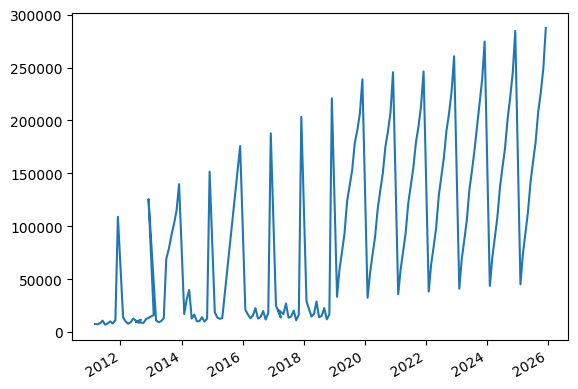

In [98]:
df['全国一般公共预算支出'].plot()